In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ERROR: Error in parse(text = input): <text>:5:8: unexpected symbol
4: 
5: import numpy
          ^


# Bike-Share Data Analysis Case Study
## Analyzing Differences Between Casual Riders and Annual Members

## 1.0 Introduction

This project analyzes bike-share trip data to identify rider behavior, ride patterns and usage trends. The analysis includes data cleaning, feature engineering, exploratory data analysis and visualization using R and tidyverse tools.

The goal of this project is to generate insights that can support operational planning and customer engagement strategies for bike-share services.

## 2.0 Business Problem
We are analyzing bike-share data to understand how casual riders and annual members use the service differently.

## 3.0 Load Required Libraries

In [1]:
library(tidyverse)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## 4.0 Define Data Path

In [3]:
path <- "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset"

## 5.0 Load File Names

In [4]:
files <- list.files(path, full.names = TRUE)
files

[1] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202011-divvy-tripdata.csv"
 [2] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202012-divvy-tripdata.csv"
 [3] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202101-divvy-tripdata.csv"
 [4] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202102-divvy-tripdata.csv"
 [5] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202103-divvy-tripdata.csv"
 [6] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202104-divvy-tripdata.csv"
 [7] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202105-divvy-tripdata.csv"
 [8] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202106-divvy-tripdata.csv"
 [9] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202107-divvy-tripdata.csv"
[10] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202108-divvy-tripdata.csv"
[11] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202109-divvy-tripdata.csv"
[12] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202110-divvy-tripdata.csv"
[13] "/kaggle/input/datasets/snehapirahalathan/case-study-1-bike-share-dataset/202111-divvy-tripdata.csv"

## 6.0 Merge All Monthly Data

In [5]:
bike_data <- files %>%
map_df(~ read.csv(.x, colClasses = "character"))

## 7.0 Preview Dataset

In [6]:
head(bike_data)

str(bike_data)

summary(bike_data)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,BD0A6FF6FFF9B921,electric_bike,2020-11-01 13:36:00,2020-11-01 13:45:40,Dearborn St & Erie St,110,St. Clair St & Erie St,211,41.8941765,-87.62912733333333,41.89443416666667,-87.62337916666667,casual
2,96A7A7A4BDE4F82D,electric_bike,2020-11-01 10:03:26,2020-11-01 10:14:45,Franklin St & Illinois St,672,Noble St & Milwaukee Ave,29,41.89095866666667,-87.63534283333334,41.900675,-87.66248033333333,casual
3,C61526D06582BDC5,electric_bike,2020-11-01 00:34:05,2020-11-01 01:03:06,Lake Shore Dr & Monroe St,76,Federal St & Polk St,41,41.880982833333334,-87.61675416666667,41.8720545,-87.62955033333333,casual
4,E533E89C32080B9E,electric_bike,2020-11-01 00:45:16,2020-11-01 00:54:31,Leavitt St & Chicago Ave,659,Stave St & Armitage Ave,185,41.89549916666667,-87.682013,41.9177445,-87.69139183333333,casual
5,1C9F4EF18C168C60,electric_bike,2020-11-01 15:43:25,2020-11-01 16:16:52,Buckingham Fountain,2,Buckingham Fountain,2,41.87649733333333,-87.620358,41.876448333333336,-87.620338,casual
6,7259585D8276D338,electric_bike,2020-11-14 15:55:17,2020-11-14 16:44:38,Wabash Ave & 16th St,72,Lake Shore Dr & Monroe St,76,41.860288833333335,-87.625806,41.880985,-87.6167735,casual


'data.frame':	5738812 obs. of  13 variables:
 $ ride_id           : chr  "BD0A6FF6FFF9B921" "96A7A7A4BDE4F82D" "C61526D06582BDC5" "E533E89C32080B9E" ...
 $ rideable_type     : chr  "electric_bike" "electric_bike" "electric_bike" "electric_bike" ...
 $ started_at        : chr  "2020-11-01 13:36:00" "2020-11-01 10:03:26" "2020-11-01 00:34:05" "2020-11-01 00:45:16" ...
 $ ended_at          : chr  "2020-11-01 13:45:40" "2020-11-01 10:14:45" "2020-11-01 01:03:06" "2020-11-01 00:54:31" ...
 $ start_station_name: chr  "Dearborn St & Erie St" "Franklin St & Illinois St" "Lake Shore Dr & Monroe St" "Leavitt St & Chicago Ave" ...
 $ start_station_id  : chr  "110" "672" "76" "659" ...
 $ end_station_name  : chr  "St. Clair St & Erie St" "Noble St & Milwaukee Ave" "Federal St & Polk St" "Stave St & Armitage Ave" ...
 $ end_station_id    : chr  "211" "29" "41" "185" ...
 $ start_lat         : chr  "41.8941765" "41.89095866666667" "41.880982833333334" "41.89549916666667" ...
 $ start_lng         : c

   ride_id          rideable_type       started_at          ended_at        
 Length:5738812     Length:5738812     Length:5738812     Length:5738812    
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
 start_station_name start_station_id   end_station_name   end_station_id    
 Length:5738812     Length:5738812     Length:5738812     Length:5738812    
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
  start_lat          start_lng           end_lat            end_lng         
 Length:5738812     Length:5738812     Length:5738812     Length:5738812    
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
 member_casual     
 Length:5738812    
 Class :character  
 Mode  :characte

## 8.0 Data Cleaning
Before analysis, the dataset is cleaned by checking for missing values, duplicates and correcting data types.

### 8.1 Check Missing Values
We first identify missing values in each column

In [7]:
colSums(is.na(bike_data))

ride_id      rideable_type         started_at           ended_at 
                 0                  0                  0                  0 
start_station_name   start_station_id   end_station_name     end_station_id 
                 0                  0                  0                  0 
         start_lat          start_lng            end_lat            end_lng 
                 0                  0                  0                  0 
     member_casual 
                 0

### 8.2 Handle Missing Values
Rows with missing values are removed to ensure data quality.

In [8]:
bike_data <- bike_data %>%
drop_na()

### 8.3 Remove Duplicate Records
Duplicate rows are removed to avoid bias in analysis

In [9]:
bike_data <- bike_data %>%
distinct()

### 8.4 Convert Data Types
Date-Time columns are converted to proper datetime for analysis.

In [10]:
bike_data <- bike_data %>%
mutate(
    started_at = as.POSIXct(started_at),
    ended_at = as.POSIXct(ended_at)
)

## 9.0 Feature Engineering
Feature engineering is performed to create new variables that can provide deeper into rider behavior and ride patterns.

### 9.1 Calculate Ride Duration

A new variable called 'ride_length' is created to measure the duration of each ride in minutes.

In [11]:
bike_data <- bike_data %>%
mutate(
    ride_length = as.numeric(
        difftime(ended_at, started_at, units = "mins")
    )
)

### 9.2 Extract Day of the Week
The day of the week is extracted from the ride start time to analyze weekly riding patterns.

In [12]:
bike_data <- bike_data %>%
mutate(
    day_of_week = weekdays(started_at)
)

### 9.3 Extract Month
The month variable is created to study monthly ride trends and seasonal patterns.

In [13]:
bike_data <- bike_data %>%
mutate(
    month = format(started_at, "%Y-%m")
)


## 10.0 Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is conducted to identify trends, patterns and rider behavior within the bike-share dataset. This section focuses on analyzing ride duration and bike usage patterns.

### 10.1 Most Popular Ride Types
This analysis examines the frequency of different rideable bike types used by riders.

In [14]:
bike_data %>%
count(rideable_type) %>%
arrange(desc(n))

rideable_type,n
<chr>,<int>
classic_bike,3221009
electric_bike,2045802
docked_bike,472001


#### Interpretation

The results indicate that 'classic_bike' is the most frequently used bike type, with over 3.2 million rides recorded. This suggests that riders may prefer classic bikes due to their accessibility, familiarity or wider availability compared to other bike types.
'electric_bike' usage was also substantial, exceeding 2 million rides, indicating growing adoption of electric bikes among users.
In contrast, `docked_bike` recorded significantly fewer rides, which may suggest lower rider preference for this bike type.

### 10.2 Peak Usage by Day of the Week

This analysis identifies which days experience the highest ride activity.

In [15]:
bike_data %>%
count(day_of_week)

day_of_week,n
<chr>,<int>
Friday,823347
Monday,729504
Saturday,1023091
Sunday,888692
Thursday,745655
Tuesday,763498
Wednesday,765025


#### Interpretation

The results highlight clear weekly riding patterns, with Saturday showing the highest ride activity, followed closely by Sunday. This suggests that weekends are particularly popular for bike usage, likely reflecting recreational trips, leisure outings or family activities. In contrast, weekdays such as Monday and Thursday record lower ride counts, which may indicate that riders use bikes more selectively for commuting or short errands during the workweek. These insights are valuable for bike-share operators, as they can guide resource allocation, such as ensuring higher bike availability on weekends and adjusting maintenance schedules to match demand. Additionally, the weekday vs. weekend distinction provides a foundation for comparing casual riders, who may favor leisure trips, against members, who often ride during commuting hours. 

### 10.3 Average Ride Duration
This analysis calculates the average duration of rides in minutes.

In [16]:
mean(bike_data$ride_length,na.rm = TRUE)

[1] 20.13348

#### Interpretation
The calculated average ride duration of approximately 20 minutes provides a benchmark for understanding typical trip lengths within the dataset. This suggests that most rides are relatively short, aligning with common commuting or quick errand patterns rather than extended leisure trips. However, the mean can be influenced by outliers, either unusually long or short rides, so it should be considered alongside other measures like the median and distribution plots. From an operational perspective, knowing the average duration helps bike-share providers anticipate turnover rates, optimize bike availability and plan maintenance schedules. It also offers valuable insights into rider behavior, such as whether casual riders tend to take longer trips compared to members or if seasonal factors influence ride duration trends. 

## 11.0 Data Visualization
Data visualization is used to explore patterns, trends and rider behavior within the bike-share dataset. The following charts provide insights into ride frequency, bike preferences, ride duration and seasonal trends.

### 11.1 Ride Frequency by Day of the Week
This visualization shows the number of rides taken on each day of the week. It helps identify which days experience the highest rider activity.

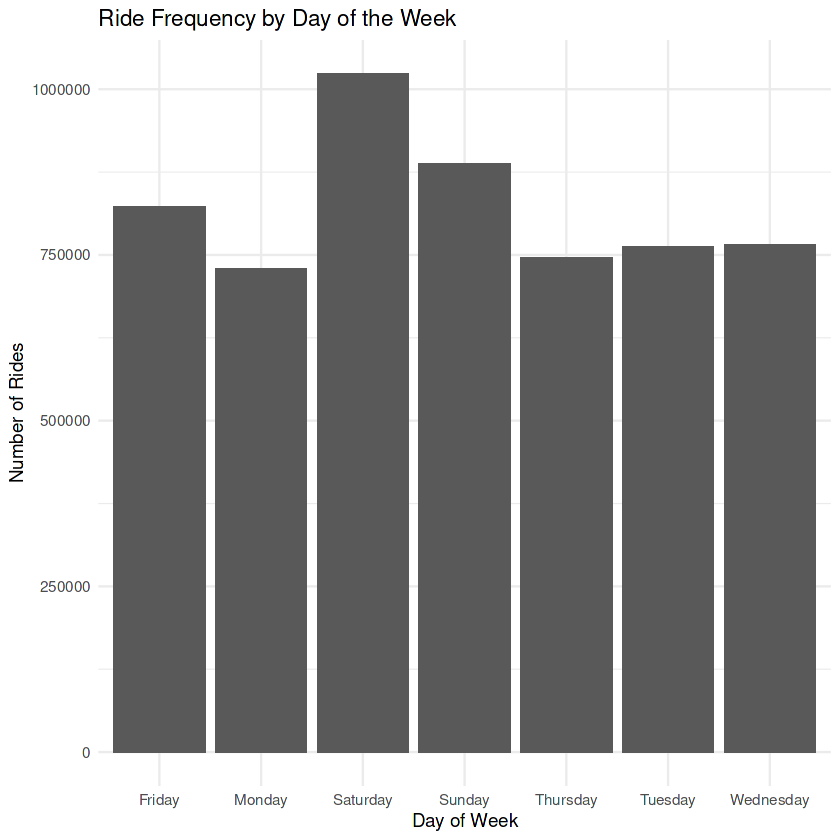

In [17]:
ggplot(bike_data, aes(x = day_of_week))+
geom_bar()+
labs(
    title = "Ride Frequency by Day of the Week",
    x = "Day of Week",
    y = "Number of Rides"
)+
theme_minimal()

#### Interpretation
The visualization highlights distinct variations in ride activity across the week. Saturday records the highest number of rides, exceeding one million, which strongly suggests that weekends are favored for recreational or leisure trips. Sunday also shows elevated usage, reinforcing the weekend trends. In contrast, Monday has the lowest ride frequency, likely reflecting reduced demand after the weekend or limited commuting reliance on bike-share services. The midweek days (Tuesday through Thursday) show relatively steady ride counts, indicating consistent weekday usage patterns. These insights are valuable for understanding rider behavior and for operational planning, where bike-share providers can anticipate higher demand on weekends, ensuring adequate bike availability, while weekdays may require a focus on commuter support and balanced distribution. The chart also provides a foundation for deeper analysis, such as comparing casual versus member riders to see how their weekly usage patterns differ. 

### 11.2 Distribution of Rideable Bike Types
This chart displays the frequency of different bike types used by riders.

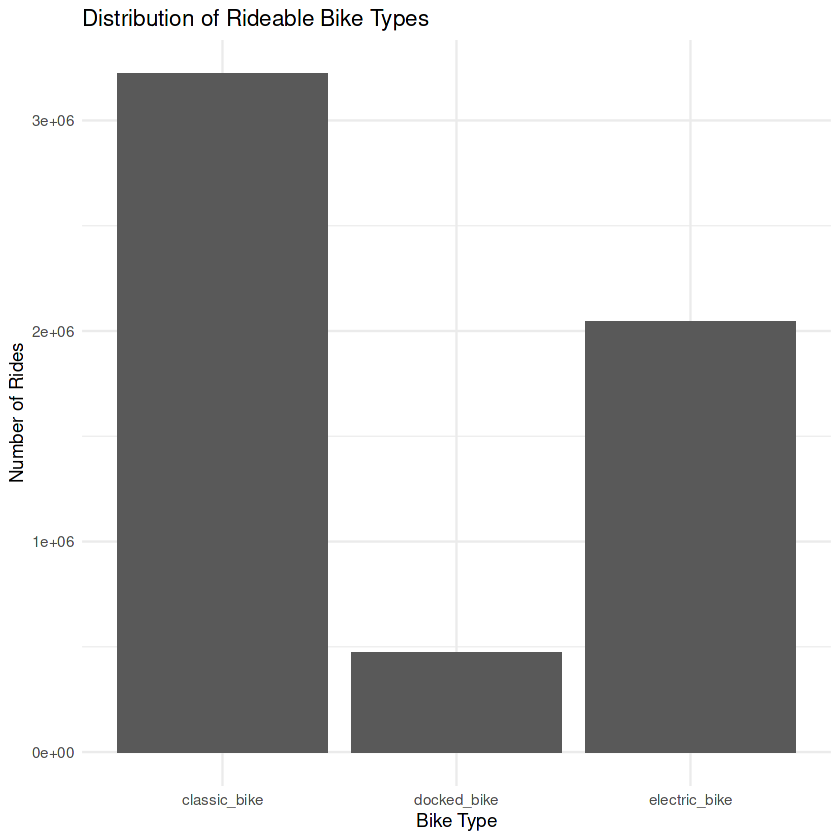

In [18]:
ggplot(bike_data, aes(x= rideable_type))+
geom_bar()+
labs(
    title = "Distribution of Rideable Bike Types",
    x="Bike Type",
    y= "Number of Rides"
)+
theme_minimal()

#### Interpretation
The chart clearly illustrates rider preferences across the three available bike types. *Classic bikes* dominate usage, with nearly 3 million rides, suggesting they are the most accessible and familiar option for riders, which highlights growing interest in faster, more convenient travel, possibly for longer commutes or to reduce physical effort. In contrast, docked bikes account for the smallest share, under half a million rides, which may reflect limited availability, less distribution provides insights for bike-share operators: maintaining a large fleet of classic bikes ensures broad accessibility, while expanding electric bike offerings could meet rising demand. The lower docked bike usage may indicate a need to reassess their role in the system or focus resources on more popular alternatives.  

### 11.3 Monthly Ride Trends
This visualization examines ride activity across different months to identify possible seasonal patterns. 

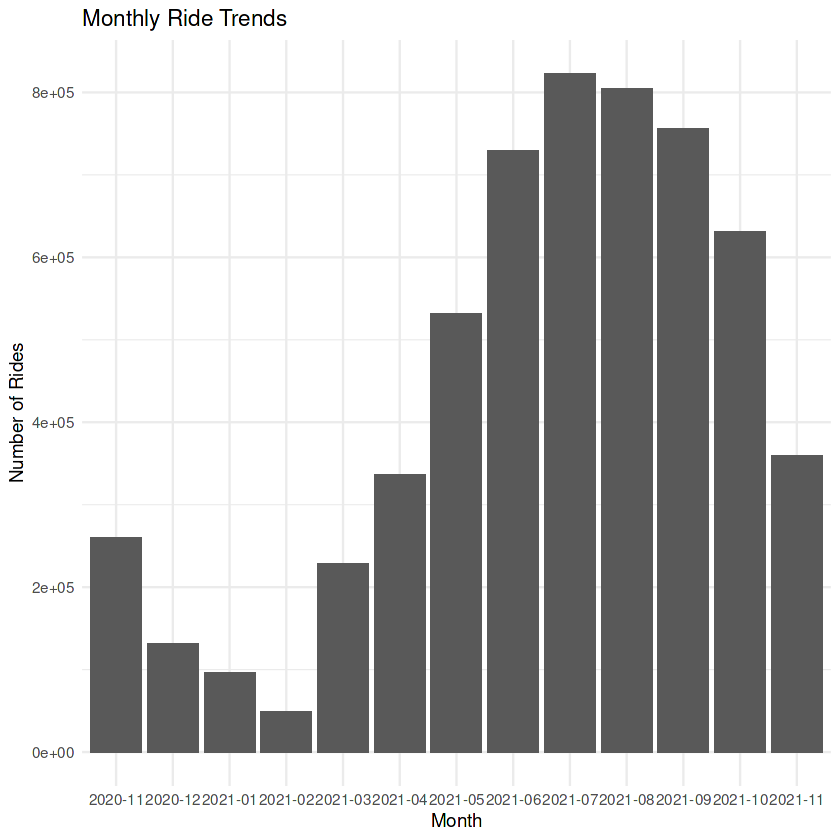

In [19]:
ggplot(bike_data, aes(x=month))+
geom_bar()+
labs(
    title = "Monthly Ride Trends",
    x = "Month",
    y = "Number of Rides"
)+
theme_minimal()

#### Interpretation 
The visualization reveals clear seasonal fluctuations in ride activity across the year. Ride counts begin at lower levels in late 2020, then steadily increase through early 2021, peaking during the summer months of June to August. This peak likely reflects favorable weather conditions, longer daylight hours and increased recreational activity during the mid-year period. After summer, ride frequency declines toward November, suggesting reduced demand as colder or wetter conditions set in. These monthly trends highlight the strong influence of seasonality and climate on rider behavior. For bike-share operators, such insights are critical for planning fleet distribution, maintenance schedules and promotional campaigns. For example, ensuring higher bike availability during peak summer months and offering incentives during off-peak seasons could help balance demand. The chart also provides a foundation for comparing casual versus member riders, as seasonal effects may impact these groups differently, such as, casual riders may favor summer leisure trips, while members maintain steadier commuting patterns throughout the year. 

### 11.4 Ride Duration Distribution
This histogram visualizes the distribution of ride durations in minutes.

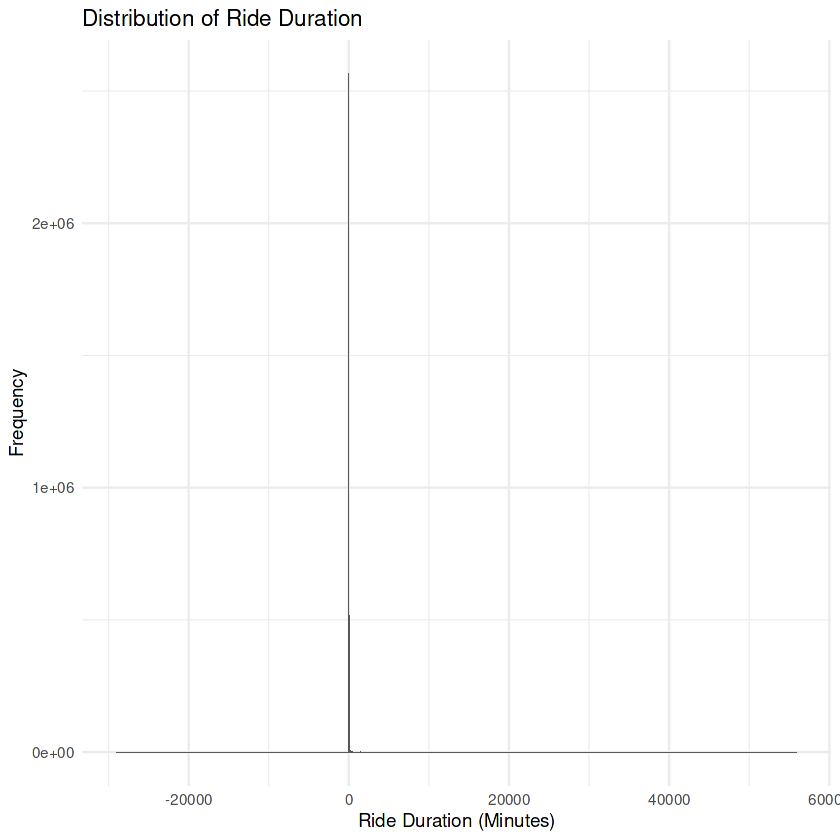

In [20]:
ggplot(bike_data, aes(x = ride_length))+
geom_histogram(binwidth = 10)+
labs(
    title = "Distribution of Ride Duration",
    x = "Ride Duration (Minutes)",
    y = "Frequency"
)+
theme_minimal()

#### Interpretation
The histogram reveals a highly skewed distribution of ride durations, with an overwhelming concentration of trips clustered near zero minutes. This spike suggests either a large number of extremely short rides or potential data anomalies, such as system errors or incomplete trip records. Beyond this cluster, the distribution flattens out, indicating that longer rides are relatively rare. Such skewness highlights the importance of cleaning and validating the dataset before deeper analysis, as outliers or erroneous values can distort averages and misrepresent rider behavior. From an analytical perspective, examining the median ride length or filtering out implausible durations (e.g., negative or excessively long values) would provide a clearer picture of typical usage. Operationally, understanding the true distribution of ride lengths helps bike-share providers anticipate turnover rates, optimize bike availability and tailor services to rider needs, whether for short commutes or longer leisure trips. 

### 11.5 Member vs Casual Riders
This visualization compares ride frequency between member and casual riders

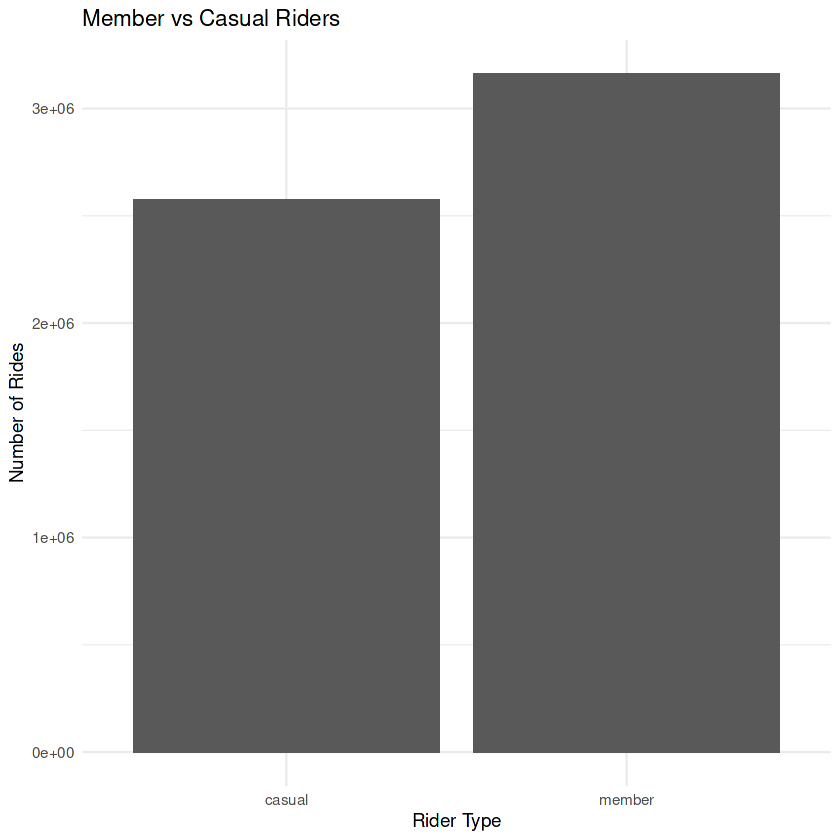

In [21]:
ggplot(bike_data, aes(x = member_casual))+
geom_bar()+
labs(
    title = "Member vs Casual Riders",
    x = "Rider Type",
    y = "Number of Rides"
)+
theme_minimal()

#### Interpretation
The visualization highlights a clear difference in ride frequency between subscribed members and casual riders. Members account for a significantly higher number of rides, approaching 3 million, suggesting that they rely on the service more consistently for commuting, daily errands or routine travel. Casual riders, while fewer in number, still represent a substantial portion of total usage and are more likely associated with leisure trips, tourism or occasional transportation needs. This segmentation provides valuable insights into rider behavior. Members demonstrate long-term commitment and steady demand, while casual riders reflect more flexible, seasonal or recreational usage patterns. For bike-share operators, understanding this distinction is critical for tailoring services, ensuring reliable availability and commuter-friendly features for members, while designing promotions, weekend campaigns or tourist-oriented offerings to attract casual users. The comparison also underscores opportunities to convert casual riders into members by highlighting the benefits of subscription plans, such as cost savings and convenience.

### 12.1 Key Findings

- Ride activity was generally higher during weekends, suggesting increased recreational and leisure usage.
- Classic bikes were the most frequently used bike among riders.
- Monthly ride patterns indicated possible seasonal influences on bike usage trends.
- Most rides were relatively short in duration, although a small number of unusually long rides were observed.
- Casual riders and annual members displayed different rising frequencies and usage behaviors, indicating distinct customer patterns. 

## 13.0 Conclusion

This project analyzed bike-share ride data using data cleaning, feature engineering, exploratory data analysis and visualization techniques. 

Several important trends were identified, including differences in ride activity across weekdays, bike type preferences, customer riding behavior and ride duration patterns. These findings provide useful insights into customer usage patterns and operational demand within the bike-share system.

Overall, this project demonstrates the complete data analysis workflow, from raw data preparation to generating actionable insights through visualization and interpretation.

## 14.0 Recommendations

- Increase bike availability during weekends to accommodate higher ride demand.
- Promote underutilized bike types through targeted marketing campaigns or promotional incentives.
- Prepare for seasonal demand fluctuations by adjusting bike allocation and operational planning across different months.
- Develop targeted membership campaigns to encourage casual riders to convert into annual members.
- Monitor unusually long ride durations to identify potential operational inefficiencies or data quality issues.

These recommendations may help improve customer conversion strategies, optimize operational planning and enhance customer engagement within the bike-share system.

## 15.0 Limitations

Although the analysis provides insights into bike-share rider behavior, several limitations should be acknowledged. 

- The analysis was conducted using historical bike-share trip data only which may not fully capture current rider behavior or operational conditions.
- External factors such as weather conditions, public holidays, fuel prices, tourism activity and local events were not included in the analysis. These factors may significantly influence ride frequency and rider behavior.
- The data cleaning procedures, such as removing missing values and duplicate records, may have resulted in the loss of potentially useful information.
- The analysis relied mainly on exploratory analysis and visualization techniques. More advanced statistical or predictive modelling methods were not applied within this project.
- Ride duration calculations assumed that all recorded timestamps were accurate and properly recorded within the dataset.
- The project focused on identifying general behavioral patterns between casual riders and annual members, but individual rider motivations and preferences could not be directly measured from the available data.

Despite these limitations, the analysis successfully identified several meaningful trends and provided valuable insights into bike-share usage behavior and operational demand.

## Tools Used
- R Programming
- tidyverse
- ggplot2
- Kaggle Notebook Environment